## v4 — decomposed targets at native resolution

The turning point. The box is replaced by `side` + four regressed quantities,
and 19 hand-crafted shadow descriptors are fused into the pooled trunk
features. Validation side accuracy hits **1.000** on the first epochs -- the
side of the frame turns out to be trivially readable from the shadow -- while
direction never clears **0.547**, i.e. chance. Early stopped at epoch 29 in
7.9 minutes.

---

**Provenance.** This is an as-run artifact from the BrabantHack 2026 DEMCON
challenge, preserved with its original outputs so the numbers quoted in
[`docs/experiments.md`](../docs/experiments.md) can be checked against the logs
that produced them. It ran on a shared GPU server, so the paths (`/home/y2a/...`) and the `CUDA_VISIBLE_DEVICES` pin are the machine's, not yours.

The method it arrived at has since been rewritten as a tested package under
[`src/shadow_detection/`](../src/shadow_detection); run
`shadow-detection train --help` rather than this notebook.


# V4 Full Res: Their Decomposed Model @ 720×480 + Our Features

In [1]:
import json, os, random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from PIL import Image
from scipy.ndimage import sobel, gaussian_filter
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

os.environ['CUDA_VISIBLE_DEVICES'] = '4'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available(): print(f'GPU: {torch.cuda.get_device_name(0)}')

TRAIN_DIR = Path('/home/y2a/detection-by-shadow/train_data/train_data')
TEST_DIR = Path('/home/y2a/detection-by-shadow/test_data/test_data')
SAMPLE_CSV = Path('/home/y2a/detection-by-shadow/submission_example.csv')
SAVE_DIR = Path('/home/y2a/Hackaton/shadow_detection')
SAVE_DIR.mkdir(parents=True, exist_ok=True)

IMG_W, IMG_H = 720, 480
INPUT_SIZE = (480, 720)  # FULL RES (H, W)
BATCH_SIZE = 32          # smaller batch for full res
NUM_EPOCHS = 80
LR = 1e-3
BACKBONE_LR = 1e-4
WEIGHT_DECAY = 1e-4
VAL_SPLIT = 0.15
PATIENCE = 15
SEED = 42

torch.manual_seed(SEED); random.seed(SEED); np.random.seed(SEED)

Device: cuda
GPU: NVIDIA RTX 6000 Ada Generation


In [2]:
def extract_geometric_features(img_array):
    if len(img_array.shape)==3 and img_array.shape[2]==4: img_array=img_array[:,:,:3]
    gray = np.mean(img_array.astype(np.float32), axis=2)
    H, W = gray.shape
    rm = np.median(gray, axis=1, keepdims=True)
    sm = gray < (rm * 0.85)
    rs = int(H*0.4); road = sm[rs:,:]
    f = np.zeros(19, dtype=np.float32)
    f[0]=np.mean(gray[int(H*0.625):,:20])/255; f[1]=np.mean(gray[int(H*0.625):,-20:])/255
    f[2]=f[0]/(f[1]+1e-6)
    ys,xs=np.where(road)
    if len(xs)>50:
        f[3]=np.mean(xs)/W; f[4]=(np.mean(ys)+rs)/H; f[5]=np.std(xs)/W; f[6]=np.std(ys)/H
        f[7]=len(xs)/(road.shape[0]*road.shape[1])
        lm=np.sum(road[:,:W//2]); rm2=np.sum(road[:,W//2:]); f[8]=lm/(lm+rm2+1e-6)
        cd=np.sum(road,axis=0).astype(float); f[9]=np.argmax(cd)/W
        f[10]=np.average(np.arange(W).astype(float),weights=cd+1e-6)/W
        f[11]=np.sum(road[:,:30])/(road.shape[0]*30); f[12]=np.sum(road[:,-30:])/(road.shape[0]*30)
        if len(xs)>100:
            cov=np.cov(xs-np.mean(xs),ys-np.mean(ys)); _,ev=np.linalg.eigh(cov)
            f[13]=np.arctan2(ev[1,1],ev[0,1])/np.pi
    else: f[3:14]=0.5
    bl2=gaussian_filter(gray,sigma=20); sd=bl2-gray; r2=sd[int(H*0.58):,:]; m2=r2>8
    y2,x2=np.where(m2)
    if len(x2)>50:
        f[14]=np.mean(r2[m2])/100; f[15]=np.max(r2[m2])/100
        f[16]=np.mean(np.abs(sobel(r2,axis=1))[m2])/50
        f[17]=len(x2)/((np.max(y2)-np.min(y2)+1)*(np.max(x2)-np.min(x2)+1)+1e-6)
        f[18]=np.percentile(r2[m2],90)/100
    return f

print('Features ready')

Features ready


In [3]:
def load_annotations(data_dir):
    png_files = {p.stem: p for p in data_dir.rglob('*.png')}
    samples = []
    t0 = time.time()
    json_files = sorted(data_dir.rglob('*.json'))
    for i, jf in enumerate(json_files):
        if i%300==0: print(f'  {i}/{len(json_files)} ({time.time()-t0:.0f}s)')
        with open(jf) as f: ann = json.load(f)
        fname = ann['file_name']
        if fname not in png_files: continue
        tl, br = ann['bbox']['top_left'], ann['bbox']['bottom_right']
        xmin, ymin, xmax, ymax = tl[0], tl[1], br[0], br[1]
        w, h = xmax-xmin, ymax-ymin
        yc = (ymin+ymax)/2
        side = 0 if xmin < 0 else 1
        dist = abs(xmin) if side == 0 else xmax - IMG_W
        img = np.array(Image.open(png_files[fname]).convert('RGB'))
        geo = extract_geometric_features(img)
        samples.append({
            'img_path': str(png_files[fname]), 'file_name': fname,
            'xmin': xmin, 'ymin': ymin, 'xmax': xmax, 'ymax': ymax,
            'side': side, 'distance_from_edge': dist,
            'bbox_width': w, 'bbox_height': h, 'y_center': yc,
            'direction': ann['walking_into_frame_bool'], 'geo': geo,
        })
    return samples

print('Loading annotations + geo features...')
train_samples = load_annotations(TRAIN_DIR)
print(f'Loaded {len(train_samples)} samples')

target_keys = ['distance_from_edge', 'bbox_width', 'bbox_height', 'y_center']
target_stats = {}
for k in target_keys:
    vals = np.array([s[k] for s in train_samples])
    target_stats[k] = {'mean': float(vals.mean()), 'std': float(vals.std())}
    print(f'  {k:>20s}: mean={vals.mean():.2f}, std={vals.std():.2f}')

def norm_t(v, k): return (v - target_stats[k]['mean']) / (target_stats[k]['std'] + 1e-8)
def denorm_t(v, k): return v * (target_stats[k]['std'] + 1e-8) + target_stats[k]['mean']

Loading annotations + geo features...
  0/1693 (0s)
  300/1693 (21s)
  600/1693 (40s)
  900/1693 (60s)
  1200/1693 (79s)
  1500/1693 (99s)
Loaded 1693 samples
    distance_from_edge: mean=208.59, std=45.14
            bbox_width: mean=80.87, std=29.86
           bbox_height: mean=172.91, std=34.67
              y_center: mean=309.34, std=14.27


In [4]:
stratify = [s['side']*2 + s['direction'] for s in train_samples]
train_data, val_data = train_test_split(train_samples, test_size=VAL_SPLIT, random_state=SEED, stratify=stratify)
print(f'Train: {len(train_data)}, Val: {len(val_data)}')

class ShadowDatasetFullRes(Dataset):
    def __init__(self, samples, target_stats, augment=False):
        self.samples = samples
        self.ts = target_stats
        self.augment = augment
        # Full res: just normalize, no resize
        self.normalize = transforms.Normalize([0.422,0.413,0.394],[0.167,0.174,0.233])
        self.color_jitter = transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05)
        self.blur = transforms.GaussianBlur(3, sigma=(0.1,1.0))
    
    def __len__(self): return len(self.samples)
    
    def __getitem__(self, idx):
        s = self.samples[idx]
        img = Image.open(s['img_path']).convert('RGB')  # already 720x480
        side = s['side']
        direction = s['direction']
        geo = s['geo'].copy()
        
        do_flip = self.augment and random.random() < 0.5
        if do_flip:
            img = img.transpose(Image.FLIP_LEFT_RIGHT)
            side = 1 - side
            direction = 1 - direction
            geo[0],geo[1] = geo[1],geo[0]; geo[2]=geo[0]/(geo[1]+1e-6)
            geo[3]=1-geo[3]; geo[8]=1-geo[8]; geo[9]=1-geo[9]; geo[10]=1-geo[10]
            geo[11],geo[12] = geo[12],geo[11]
        
        if self.augment:
            if random.random() < 0.8: img = self.color_jitter(img)
            if random.random() < 0.2: img = self.blur(img)
        
        img = transforms.ToTensor()(img)
        img = self.normalize(img)
        
        reg = torch.tensor([
            norm_t(s['distance_from_edge'], 'distance_from_edge'),
            norm_t(s['bbox_width'], 'bbox_width'),
            norm_t(s['bbox_height'], 'bbox_height'),
            norm_t(s['y_center'], 'y_center'),
        ], dtype=torch.float32)
        
        return (img, torch.tensor(side, dtype=torch.long), reg,
                torch.tensor(direction, dtype=torch.long),
                torch.from_numpy(geo).float())

train_ds = ShadowDatasetFullRes(train_data, target_stats, augment=True)
val_ds = ShadowDatasetFullRes(val_data, target_stats, augment=False)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

# Verify
imgs, sides, regs, dirs, geos = next(iter(train_loader))
print(f'Batch: imgs={imgs.shape}, geos={geos.shape}')  # should be [B, 3, 480, 720]

Train: 1439, Val: 254
Batch: imgs=torch.Size([32, 3, 480, 720]), geos=torch.Size([32, 19])


In [5]:
class ShadowModelFullRes(nn.Module):
    def __init__(self, num_geo=19, dropout=0.3):
        super().__init__()
        backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        self.backbone = nn.Sequential(*list(backbone.children())[:-1])
        self.shared_proj = nn.Sequential(
            nn.Linear(2048 + num_geo, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(dropout),
        )
        self.side_head = nn.Sequential(
            nn.Linear(512, 128), nn.ReLU(), nn.Dropout(dropout), nn.Linear(128, 2),
        )
        self.regression_head = nn.Sequential(
            nn.Linear(512, 256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, 128), nn.ReLU(), nn.Linear(128, 4),
        )
        self.direction_head = nn.Sequential(
            nn.Linear(512, 128), nn.ReLU(), nn.Dropout(dropout), nn.Linear(128, 2),
        )
    
    def forward(self, x, geo=None):
        feats = self.backbone(x).flatten(1)
        if geo is not None:
            feats = torch.cat([feats, geo], dim=1)
        shared = self.shared_proj(feats)
        return self.side_head(shared), self.regression_head(shared), self.direction_head(shared)

model = ShadowModelFullRes().to(device)
print(f'Params: {sum(p.numel() for p in model.parameters()):,}')

Params: 24,864,456


In [6]:
criterion_ce = nn.CrossEntropyLoss()
criterion_l1 = nn.SmoothL1Loss()
W_SIDE, W_REG, W_DIR = 1.0, 5.0, 1.0

backbone_params = [p for n,p in model.named_parameters() if 'backbone' in n]
head_params = [p for n,p in model.named_parameters() if 'backbone' not in n]
optimizer = optim.AdamW([
    {'params': backbone_params, 'lr': BACKBONE_LR},
    {'params': head_params, 'lr': LR},
], weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
scaler = torch.amp.GradScaler('cuda')

best_val_loss = float('inf')
patience_counter = 0
history = {'train_loss':[], 'val_loss':[], 'val_side':[], 'val_dir':[]}
t_start = time.time()

print(f'Full res {IMG_W}x{IMG_H}, batch={BATCH_SIZE}')

for epoch in range(NUM_EPOCHS):
    t_ep = time.time()
    model.train()
    tl_sum, tn = 0, 0
    for imgs, sides, regs, dirs, geos in train_loader:
        imgs=imgs.to(device); sides=sides.to(device); regs=regs.to(device)
        dirs=dirs.to(device); geos=geos.to(device)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda'):
            sl,rp,dl = model(imgs, geos)
            loss = W_SIDE*criterion_ce(sl,sides) + W_REG*criterion_l1(rp,regs) + W_DIR*criterion_ce(dl,dirs)
        scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
        tl_sum += loss.item()*imgs.size(0); tn += imgs.size(0)
    
    model.eval()
    vl_sum, vn, sc, dc = 0, 0, 0, 0
    with torch.no_grad():
        for imgs, sides, regs, dirs, geos in val_loader:
            imgs=imgs.to(device); sides=sides.to(device); regs=regs.to(device)
            dirs=dirs.to(device); geos=geos.to(device)
            with torch.amp.autocast('cuda'):
                sl,rp,dl = model(imgs, geos)
                loss = W_SIDE*criterion_ce(sl,sides) + W_REG*criterion_l1(rp,regs) + W_DIR*criterion_ce(dl,dirs)
            vl_sum += loss.item()*imgs.size(0)
            sc += (sl.argmax(1)==sides).sum().item()
            dc += (dl.argmax(1)==dirs).sum().item()
            vn += imgs.size(0)
    
    tl, vl = tl_sum/tn, vl_sum/vn
    vsa, vda = sc/vn, dc/vn
    scheduler.step(vl)
    history['train_loss'].append(tl); history['val_loss'].append(vl)
    history['val_side'].append(vsa); history['val_dir'].append(vda)
    
    saved = ''
    if vl < best_val_loss:
        best_val_loss = vl; patience_counter = 0
        torch.save(model.state_dict(), str(SAVE_DIR / 'best_v4_fullres.pth'))
        saved = ' *BEST*'
    else:
        patience_counter += 1
    
    if epoch%5==0 or saved:
        print(f'Ep {epoch:3d} ({time.time()-t_ep:.0f}s) | T:{tl:.4f} V:{vl:.4f} | side:{vsa:.3f} dir:{vda:.3f}{saved}')
    
    if patience_counter >= PATIENCE:
        print(f'Early stopping at epoch {epoch}')
        break

print(f'\nDone in {(time.time()-t_start)/60:.1f}min')

Full res 720x480, batch=32
Ep   0 (15s) | T:2.5703 V:2.9167 | side:0.933 dir:0.496 *BEST*
Ep   1 (17s) | T:1.7685 V:1.5152 | side:1.000 dir:0.547 *BEST*
Ep   3 (16s) | T:1.5265 V:1.5070 | side:1.000 dir:0.504 *BEST*
Ep   4 (16s) | T:1.4617 V:1.3857 | side:1.000 dir:0.520 *BEST*
Ep   5 (16s) | T:1.4754 V:1.5166 | side:1.000 dir:0.492
Ep  10 (17s) | T:1.3324 V:1.4362 | side:1.000 dir:0.543
Ep  14 (16s) | T:1.0670 V:1.3687 | side:1.000 dir:0.531 *BEST*
Ep  15 (16s) | T:1.0122 V:1.4093 | side:1.000 dir:0.512
Ep  20 (17s) | T:0.8810 V:1.5889 | side:1.000 dir:0.484
Ep  25 (15s) | T:0.5255 V:2.1618 | side:1.000 dir:0.508
Early stopping at epoch 29

Done in 7.9min


In [7]:
# Generate submission with TTA
model.load_state_dict(torch.load(str(SAVE_DIR / 'best_v4_fullres.pth'), map_location=device))
model.eval()

normalize = transforms.Normalize([0.422,0.413,0.394],[0.167,0.174,0.233])
sample_sub = pd.read_csv(SAMPLE_CSV)
predictions = []

with torch.no_grad():
    for _, row in sample_sub.iterrows():
        stem = row['id']
        img_path = TEST_DIR / f'{stem}.png'
        img_raw = np.array(Image.open(img_path).convert('RGB'))
        geo = extract_geometric_features(img_raw)
        geo_t = torch.from_numpy(geo).float().unsqueeze(0).to(device)
        
        img = Image.open(img_path).convert('RGB')
        img_t = normalize(transforms.ToTensor()(img)).unsqueeze(0).to(device)
        
        with torch.amp.autocast('cuda'):
            sl1, rp1, dl1 = model(img_t, geo_t)
        
        # TTA flip
        img_flip = img.transpose(Image.FLIP_LEFT_RIGHT)
        img_flip_t = normalize(transforms.ToTensor()(img_flip)).unsqueeze(0).to(device)
        geo_flip = geo.copy()
        geo_flip[0],geo_flip[1]=geo[1],geo[0]; geo_flip[2]=geo_flip[0]/(geo_flip[1]+1e-6)
        geo_flip[3]=1-geo[3]; geo_flip[8]=1-geo[8]; geo_flip[9]=1-geo[9]; geo_flip[10]=1-geo[10]
        geo_flip[11],geo_flip[12]=geo[12],geo[11]
        geo_flip_t = torch.from_numpy(geo_flip).float().unsqueeze(0).to(device)
        
        with torch.amp.autocast('cuda'):
            sl2, rp2, dl2 = model(img_flip_t, geo_flip_t)
        
        rp_avg = ((rp1 + rp2) / 2.0).float().cpu().numpy()[0]
        sp1 = F.softmax(sl1.float(), dim=1).cpu().numpy()[0]
        sp2 = F.softmax(sl2.float(), dim=1).cpu().numpy()[0]
        sp_avg = (sp1 + sp2[::-1]) / 2
        side = int(sp_avg.argmax())
        
        dp1 = F.softmax(dl1.float(), dim=1).cpu().numpy()[0]
        dp2 = F.softmax(dl2.float(), dim=1).cpu().numpy()[0]
        dp_avg = (dp1 + dp2[::-1]) / 2
        
        dist = denorm_t(rp_avg[0], 'distance_from_edge')
        bw = denorm_t(rp_avg[1], 'bbox_width')
        bh = denorm_t(rp_avg[2], 'bbox_height')
        yc = denorm_t(rp_avg[3], 'y_center')
        
        if side == 0:
            xmin = -dist; xmax = xmin + bw
        else:
            xmax = IMG_W + dist; xmin = xmax - bw
        ymin = yc - bh/2; ymax = yc + bh/2
        
        dir_conf = max(dp_avg)
        direction = int(dp_avg.argmax()) if dir_conf > 0.6 else -1
        
        predictions.append({'id': stem, 'xmin': xmin, 'ymin': ymin, 'xmax': xmax, 'ymax': ymax, 'direction': direction})

pred_df = pd.DataFrame(predictions)
submission = sample_sub[['id']].merge(pred_df, on='id', how='left')
submission['direction'] = submission['direction'].astype(int)
submission.to_csv(str(SAVE_DIR / 'submission_v4_fullres.csv'), index=False)
print(f'Saved: {len(submission)} rows')
print(f'Dir: {(submission["direction"]==1).sum()} in, {(submission["direction"]==0).sum()} out, {(submission["direction"]==-1).sum()} abstain')

/tmp/ipykernel_158538/2063134378.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(str(SAVE_DIR / 'best_v4_fullres.pth'), map_location=dev

Saved: 414 rows
Dir: 0 in, 0 out, 414 abstain


V4 FULL RES RESULTS
Resolution: 720x480 (original, no downscale)
Best val loss: 1.3687
Best val side: 1.000
Best val dir:  0.547
Their v1 @ 384x384: 0.590 on leaderboard


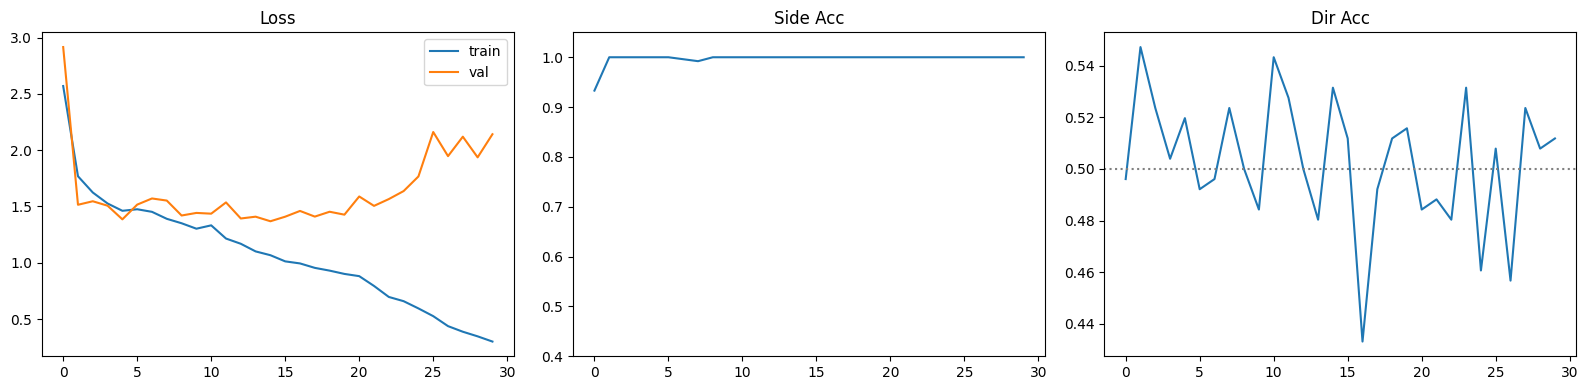

In [8]:
print('='*60)
print('V4 FULL RES RESULTS')
print('='*60)
print(f'Resolution: {IMG_W}x{IMG_H} (original, no downscale)')
print(f'Best val loss: {best_val_loss:.4f}')
print(f'Best val side: {max(history["val_side"]):.3f}')
print(f'Best val dir:  {max(history["val_dir"]):.3f}')
print(f'Their v1 @ 384x384: 0.590 on leaderboard')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(history['train_loss'], label='train'); axes[0].plot(history['val_loss'], label='val')
axes[0].set_title('Loss'); axes[0].legend()
axes[1].plot(history['val_side']); axes[1].set_title('Side Acc'); axes[1].set_ylim(0.4,1.05)
axes[2].plot(history['val_dir']); axes[2].set_title('Dir Acc'); axes[2].axhline(0.5,color='gray',ls=':')
plt.tight_layout(); plt.savefig(str(SAVE_DIR / 'v4_fullres_curves.png'), dpi=120); plt.show()